# Лабораторная 4: WGAN-GP и Conditional WGAN-GP для CelebA

В этом ноутбуке решается полный пайплайн лабораторной:

1. загружаем CelebA с Kaggle;
2. заранее вырезаем лица детектором MediaPipe Face Detector;
3. формируем датасет лиц и бинарных атрибутов CelebA;
4. обучаем **безусловный WGAN-GP** для генерации лиц без заданного признака;
5. переносим совместимые веса в **условный WGAN-GP** и дообучаем модель для генерации по признаку `Male`;
6. считаем **FID** и **Inception Score**, сохраняем кривые обучения, примеры генерации и чекпоинты.

Главная идея: обычный GAN обучает дискриминатор как классификатор real/fake, а WGAN использует **critic**, который выдаёт не вероятность, а численную оценку изображения. Разность средних оценок `D(real) - D(fake)` используется как приближение Wasserstein distance. Вариант **WGAN-GP** добавляет gradient penalty, чтобы critic был достаточно гладким и обучение не разваливалось.


In [1]:
# Проверка GPU
import os
import sys
import platform
from pathlib import Path

print("Python:", sys.version)
print("Platform:", platform.platform())

try:
    import torch
    print("Torch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
except Exception as e:
    print("Torch is not imported yet:", e)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
Torch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [ ]:
!pip -q install kaggle mediapipe torchmetrics[image] torch-fidelity tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 120.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 98.6 MB/s eta 0:00:00


In [ ]:
import os
import math
import random
import shutil
import subprocess
from pathlib import Path
from dataclasses import dataclass
from typing import Optional, Dict, List, Tuple

import cv2
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.utils import make_grid, save_image

SEED = 42

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [ ]:
@dataclass
class CFG:
    project_dir: Path = Path("/content/celeba_lab4")
    data_dir: Path = Path("/content/celeba_data")
    crop_dir: Path = Path("/content/celeba_lab4/cropped_faces_64")
    labels_csv: Path = Path("/content/celeba_lab4/cropped_labels.csv")
    runs_dir: Path = Path("/content/celeba_lab4/runs")

    image_size: int = 64
    detector_confidence: float = 0.50
    crop_margin: float = 0.35
    fallback_center_crop: bool = False
    max_preprocess_images: Optional[int] = 80000

    attr_name: str = "Male"
    train_max_images: Optional[int] = 80000
    use_balanced_dataset: bool = False
    use_horizontal_flip: bool = True
    batch_size: int = 128
    num_workers: int = 2

    z_dim: int = 128
    g_features: int = 64
    d_features: int = 64
    n_classes: int = 2

    lr: float = 1e-4
    beta1: float = 0.0
    beta2: float = 0.9
    lambda_gp: float = 10.0
    n_critic: int = 5

    epochs_uncond: int = 40
    epochs_cond: int = 25
    resume_training: bool = True

    use_ema: bool = True
    ema_decay: float = 0.999
    use_ema_for_eval: bool = True

    sample_every: int = 1
    checkpoint_every: int = 1

    eval_samples: int = 10000

cfg = CFG()
cfg.project_dir.mkdir(parents=True, exist_ok=True)
cfg.crop_dir.mkdir(parents=True, exist_ok=True)
cfg.runs_dir.mkdir(parents=True, exist_ok=True)

print(cfg)


CFG(project_dir=PosixPath('/content/celeba_lab4'), data_dir=PosixPath('/content/celeba_data'), crop_dir=PosixPath('/content/celeba_lab4/cropped_faces_64'), labels_csv=PosixPath('/content/celeba_lab4/cropped_labels.csv'), runs_dir=PosixPath('/content/celeba_lab4/runs'), image_size=64, detector_confidence=0.5, crop_margin=0.35, use_alignment=False, fallback_center_crop=False, max_preprocess_images=80000, attr_name='Male', train_max_images=80000, use_balanced_dataset=False, use_horizontal_flip=True, batch_size=128, num_workers=2, z_dim=128, g_features=64, d_features=64, n_classes=2, lr=0.0001, beta1=0.0, beta2=0.9, lambda_gp=10.0, n_critic=5, epochs_uncond=40, epochs_cond=25, resume_training=True, use_ema=True, ema_decay=0.999, use_ema_for_eval=True, sample_every=1, checkpoint_every=1, eval_samples=10000)


In [ ]:
USE_GOOGLE_DRIVE = False

try:
    from google.colab import drive
    _COLAB_DRIVE_AVAILABLE = True
except Exception:
    _COLAB_DRIVE_AVAILABLE = False

if USE_GOOGLE_DRIVE:
    if not _COLAB_DRIVE_AVAILABLE:
        raise RuntimeError("Google Drive mount доступен только в Google Colab.")
    drive.mount("/content/drive")

    cfg.project_dir = Path("/content/drive/MyDrive/celeba_lab4")
    cfg.crop_dir = cfg.project_dir / "cropped_faces_64"
    cfg.labels_csv = cfg.project_dir / "cropped_labels.csv"
    cfg.runs_dir = cfg.project_dir / "runs"

    cfg.project_dir.mkdir(parents=True, exist_ok=True)
    cfg.crop_dir.mkdir(parents=True, exist_ok=True)
    cfg.runs_dir.mkdir(parents=True, exist_ok=True)

print("project_dir:", cfg.project_dir)
print("crop_dir:", cfg.crop_dir)
print("runs_dir:", cfg.runs_dir)

project_dir: /content/celeba_lab4
crop_dir: /content/celeba_lab4/cropped_faces_64
runs_dir: /content/celeba_lab4/runs


## 1. Загрузка CelebA с Kaggle

CelebA лежит на Kaggle, поэтому ноутбуку нужны Kaggle credentials. В Colab удобнее не загружать `kaggle.json` вручную каждый раз, а сохранить секреты в боковой панели **Secrets**:

- `KAGGLE_USERNAME` — имя пользователя Kaggle;
- `KAGGLE_KEY` — ключ из Kaggle API token.

Ячейка ниже сначала ищет credentials в переменных окружения и Colab Secrets. Если секреты не найдены, остаётся fallback через ручную загрузку `kaggle.json`. После этого Kaggle CLI скачивает архив датасета и распаковывает его в `cfg.data_dir`.


In [ ]:
import json
import os
from pathlib import Path

try:
    from google.colab import files, userdata
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    files = None
    userdata = None

def get_secret(name: str):
    """Безопасно читает секрет из Colab Secrets или переменной окружения."""
    value = os.getenv(name)
    if value:
        return value

    if userdata is None:
        return None

    try:
        value = userdata.get(name)
        return value if value else None
    except Exception:
        return None

kaggle_dir = Path.home() / ".kaggle"
kaggle_dir.mkdir(parents=True, exist_ok=True)
kaggle_json = kaggle_dir / "kaggle.json"
access_token_file = kaggle_dir / "access_token"

kaggle_api_token = get_secret("KAGGLE_API_TOKEN")
if kaggle_api_token:
    os.environ["KAGGLE_API_TOKEN"] = kaggle_api_token.strip()
    access_token_file.write_text(kaggle_api_token.strip() + "\n", encoding="utf-8")
    os.chmod(access_token_file, 0o600)
    print("KAGGLE_API_TOKEN найден в Colab Secrets/env.")

kaggle_username = get_secret("KAGGLE_USERNAME")
kaggle_key = get_secret("KAGGLE_KEY")
kaggle_json_secret = get_secret("KAGGLE_JSON")

legacy_credentials = None

if kaggle_json_secret:
    try:
        legacy_credentials = json.loads(kaggle_json_secret)
        if not isinstance(legacy_credentials, dict):
            raise ValueError("KAGGLE_JSON должен быть JSON-объектом.")
        print("KAGGLE_JSON найден в Colab Secrets/env.")
    except Exception as e:
        raise ValueError(f"Не удалось распарсить KAGGLE_JSON: {e}")

elif kaggle_username and kaggle_key:
    legacy_credentials = {
        "username": kaggle_username.strip(),
        "key": kaggle_key.strip(),
    }
    print("KAGGLE_USERNAME и KAGGLE_KEY найдены в Colab Secrets/env.")

if legacy_credentials:
    required = {"username", "key"}
    if not required.issubset(legacy_credentials):
        raise ValueError("Legacy Kaggle credentials должны содержать поля 'username' и 'key'.")

    kaggle_json.write_text(json.dumps({
        "username": legacy_credentials["username"],
        "key": legacy_credentials["key"],
    }), encoding="utf-8")
    os.chmod(kaggle_json, 0o600)

    os.environ["KAGGLE_USERNAME"] = legacy_credentials["username"]
    os.environ["KAGGLE_KEY"] = legacy_credentials["key"]

if not kaggle_json.exists() and not kaggle_api_token:
    if IN_COLAB:
        print("Kaggle secrets не найдены. Загрузите kaggle.json вручную.")
        uploaded = files.upload()
        if "kaggle.json" not in uploaded:
            raise FileNotFoundError(
                "Файл kaggle.json не был загружен. "
                "Либо добавьте KAGGLE_USERNAME/KAGGLE_KEY в Colab Secrets."
            )
        shutil.move("kaggle.json", kaggle_json)
        os.chmod(kaggle_json, 0o600)
    else:
        raise FileNotFoundError(
            "Положите kaggle.json в ~/.kaggle/kaggle.json "
            "или задайте KAGGLE_USERNAME/KAGGLE_KEY."
        )

print("Kaggle auth подготовлена. Секретные значения не выводятся.")

cfg.data_dir.mkdir(parents=True, exist_ok=True)

cmd = [
    "kaggle", "datasets", "download",
    "-d", "jessicali9530/celeba-dataset",
    "-p", str(cfg.data_dir),
    "--unzip"
]
print(" ".join(cmd))
subprocess.run(cmd, check=True)

print("Готово. Примеры файлов:")
from itertools import islice
for p in islice(cfg.data_dir.rglob("*"), 20):
    print(p)


KAGGLE_API_TOKEN найден в Colab Secrets/env.
Kaggle auth подготовлена. Секретные значения не выводятся.
kaggle datasets download -d jessicali9530/celeba-dataset -p /content/celeba_data --unzip
Готово. Примеры файлов:
/content/celeba_data/list_eval_partition.csv
/content/celeba_data/img_align_celeba
/content/celeba_data/list_bbox_celeba.csv
/content/celeba_data/list_attr_celeba.csv
/content/celeba_data/list_landmarks_align_celeba.csv
/content/celeba_data/img_align_celeba/img_align_celeba
/content/celeba_data/img_align_celeba/img_align_celeba/037936.jpg
/content/celeba_data/img_align_celeba/img_align_celeba/050749.jpg
/content/celeba_data/img_align_celeba/img_align_celeba/149555.jpg
/content/celeba_data/img_align_celeba/img_align_celeba/035931.jpg
/content/celeba_data/img_align_celeba/img_align_celeba/128763.jpg
/content/celeba_data/img_align_celeba/img_align_celeba/166754.jpg
/content/celeba_data/img_align_celeba/img_align_celeba/070039.jpg
/content/celeba_data/img_align_celeba/img_alig

In [ ]:
def find_image_dir(root: Path) -> Path:
    known_candidates = [
        root / "img_align_celeba" / "img_align_celeba",
        root / "img_align_celeba",
    ]
    for p in known_candidates:
        if p.exists() and p.is_dir() and next(p.glob("*.jpg"), None) is not None:
            return p

    candidates = []
    for p in root.rglob("img_align_celeba"):
        if p.is_dir() and next(p.glob("*.jpg"), None) is not None:
            candidates.append(p)

    if not candidates:
        for p in root.rglob("*"):
            if p.is_dir() and next(p.glob("*.jpg"), None) is not None:
                candidates.append(p)

    if not candidates:
        raise FileNotFoundError("Не удалось найти папку с .jpg изображениями CelebA.")

    return sorted(candidates, key=lambda x: len(str(x)), reverse=True)[0]

def find_attr_file(root: Path) -> Path:
    names = ["list_attr_celeba.csv", "list_attr_celeba.txt"]
    for name in names:
        matches = list(root.rglob(name))
        if matches:
            return matches[0]
    raise FileNotFoundError("Не удалось найти list_attr_celeba.csv или list_attr_celeba.txt.")

def load_attr_table(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".csv":
        df = pd.read_csv(path)
        if "image_id" not in df.columns:
            df = df.rename(columns={df.columns[0]: "image_id"})
        return df

    df = pd.read_csv(path, delim_whitespace=True, skiprows=1)
    df = df.reset_index().rename(columns={"index": "image_id"})
    return df

IMG_DIR = find_image_dir(cfg.data_dir)
ATTR_PATH = find_attr_file(cfg.data_dir)
attr_df = load_attr_table(ATTR_PATH)

print("IMG_DIR:", IMG_DIR)
print("ATTR_PATH:", ATTR_PATH)
print("attr_df shape:", attr_df.shape)
display(attr_df.head())

assert cfg.attr_name in attr_df.columns, f"Нет признака {cfg.attr_name}. Доступные колонки: {list(attr_df.columns)[:10]}..."

IMG_DIR: /content/celeba_data/img_align_celeba/img_align_celeba
ATTR_PATH: /content/celeba_data/list_attr_celeba.csv
attr_df shape: (202599, 41)


,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


## 2. Предобработка: детектор лиц, квадратный crop и resize

Исходные изображения CelebA уже в основном содержат лица, но для GAN полезно привести все изображения к единому виду: лицо должно занимать примерно одинаковую область кадра. Поэтому перед обучением используется **MediaPipe Face Detector**:

1. читаем исходное изображение;
2. находим bounding box лица;
3. расширяем box на `crop_margin`, чтобы не обрезать подбородок, волосы и края лица;
4. делаем квадратный crop;
5. приводим изображение к `64×64`.

Опциональное выравнивание по глазам есть в коде, но по умолчанию выключено. На CelebA оно не обязательно: изображения уже достаточно стандартизованы, а включение alignment заметно замедляет предобработку. Если детектор не нашёл лицо, изображение пропускается. Это лучше, чем добавлять случайный center crop с фоном или неверным лицом.


In [ ]:
import urllib.request
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

DETECTOR_MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/face_detector/"
    "blaze_face_short_range/float16/1/blaze_face_short_range.tflite"
)
DETECTOR_MODEL_PATH = Path("detector.tflite")

def ensure_face_detector_model(model_path: Path = DETECTOR_MODEL_PATH) -> Path:
    if not model_path.exists():
        print(f"Downloading MediaPipe face detector model to {model_path}...")
        urllib.request.urlretrieve(DETECTOR_MODEL_URL, model_path)
    return model_path

def make_face_detector(min_conf: float = 0.5):
    model_path = ensure_face_detector_model()
    base_options = mp_python.BaseOptions(model_asset_path=str(model_path))
    options = mp_vision.FaceDetectorOptions(
        base_options=base_options,
        min_detection_confidence=float(min_conf),
    )
    return mp_vision.FaceDetector.create_from_options(options)

def detect_faces_rgb(detector, rgb: np.ndarray):
    rgb = np.ascontiguousarray(rgb.astype(np.uint8, copy=False))
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    return detector.detect(mp_image)

def detection_score(det) -> float:
    if hasattr(det, "categories") and det.categories:
        score = getattr(det.categories[0], "score", None)
        if score is not None:
            return float(score)

    if hasattr(det, "score") and det.score:
        return float(det.score[0])

    return 0.0

def best_detection(results):
    detections = getattr(results, "detections", None) if results is not None else None
    if not detections:
        return None
    return max(detections, key=detection_score)

def get_bbox_xywh(detection, image_w: int, image_h: int):
    """Return bbox in absolute pixel coordinates for both new and legacy MediaPipe APIs."""
    if hasattr(detection, "bounding_box"):
        bbox = detection.bounding_box
        return (
            float(bbox.origin_x),
            float(bbox.origin_y),
            float(bbox.width),
            float(bbox.height),
        )

    bbox = detection.location_data.relative_bounding_box
    return (
        float(bbox.xmin) * image_w,
        float(bbox.ymin) * image_h,
        float(bbox.width) * image_w,
        float(bbox.height) * image_h,
    )

def get_eye_points(detection, image_w: int, image_h: int):
    """Return two eye points in pixel coordinates when MediaPipe provides keypoints."""
    if hasattr(detection, "keypoints") and detection.keypoints and len(detection.keypoints) >= 2:
        pts = [
            np.array([kp.x * image_w, kp.y * image_h], dtype=np.float32)
            for kp in detection.keypoints[:2]
        ]
        return pts

    if hasattr(detection, "location_data"):
        keypoints = detection.location_data.relative_keypoints
        if len(keypoints) >= 2:
            pts = [
                np.array([kp.x * image_w, kp.y * image_h], dtype=np.float32)
                for kp in keypoints[:2]
            ]
            return pts

    return None

def square_crop_from_detection(
    rgb: np.ndarray,
    detection,
    out_size: int = 64,
    margin: float = 0.35,
) -> Image.Image:
    h, w = rgb.shape[:2]
    x, y, bw, bh = get_bbox_xywh(detection, w, h)

    cx = x + bw / 2.0
    cy = y + bh / 2.0
    side = max(bw, bh) * (1.0 + margin)

    x1 = int(round(cx - side / 2.0))
    y1 = int(round(cy - side / 2.0))
    x2 = int(round(cx + side / 2.0))
    y2 = int(round(cy + side / 2.0))

    pad_left = max(0, -x1)
    pad_top = max(0, -y1)
    pad_right = max(0, x2 - w)
    pad_bottom = max(0, y2 - h)

    if any(v > 0 for v in [pad_left, pad_top, pad_right, pad_bottom]):
        rgb_pad = cv2.copyMakeBorder(
            rgb,
            pad_top,
            pad_bottom,
            pad_left,
            pad_right,
            borderType=cv2.BORDER_REFLECT_101,
        )
    else:
        rgb_pad = rgb

    x1p = x1 + pad_left
    y1p = y1 + pad_top
    x2p = x2 + pad_left
    y2p = y2 + pad_top

    crop = rgb_pad[y1p:y2p, x1p:x2p]
    if crop.size == 0:
        raise ValueError("Empty crop.")

    pil = Image.fromarray(crop).resize((out_size, out_size), Image.Resampling.LANCZOS)
    return pil

def center_crop_fallback(rgb: np.ndarray, out_size: int = 64) -> Image.Image:
    h, w = rgb.shape[:2]
    side = min(h, w)
    x1 = (w - side) // 2
    y1 = (h - side) // 2
    crop = rgb[y1:y1 + side, x1:x1 + side]
    return Image.fromarray(crop).resize((out_size, out_size), Image.Resampling.LANCZOS)

def preprocess_faces(
    img_dir: Path,
    attr_df: pd.DataFrame,
    out_dir: Path,
    labels_csv: Path,
    max_images: Optional[int] = None,
    out_size: int = 64,
    margin: float = 0.35,
    min_conf: float = 0.5,
    use_alignment: bool = False,
    fallback_center_crop: bool = False,
) -> pd.DataFrame:
    out_dir.mkdir(parents=True, exist_ok=True)

    attrs = attr_df.set_index("image_id", drop=False)
    image_paths = sorted([p for p in img_dir.glob("*.jpg") if p.name in attrs.index])
    if max_images is not None:
        image_paths = image_paths[:max_images]

    detector = make_face_detector(min_conf=min_conf)

    processed = 0
    failed = 0
    skipped_existing = 0

    try:
        for img_path in tqdm(image_paths, desc="Detecting and cropping faces"):
            out_path = out_dir / img_path.name
            if out_path.exists():
                skipped_existing += 1
                continue

            bgr = cv2.imread(str(img_path))
            if bgr is None:
                failed += 1
                continue

            rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
            det = best_detection(detect_faces_rgb(detector, rgb))

            if det is None:
                if fallback_center_crop:
                    crop = center_crop_fallback(rgb, out_size=out_size)
                    crop.save(out_path, quality=95)
                    processed += 1
                else:
                    failed += 1
                continue

            try:
                crop = square_crop_from_detection(
                    rgb,
                    det,
                    out_size=out_size,
                    margin=margin,
                )
                crop.save(out_path, quality=95)
                processed += 1
            except Exception:
                if fallback_center_crop:
                    crop = center_crop_fallback(rgb, out_size=out_size)
                    crop.save(out_path, quality=95)
                    processed += 1
                else:
                    failed += 1
    finally:
        close_fn = getattr(detector, "close", None)
        if callable(close_fn):
            close_fn()

    cropped_names = sorted([p.name for p in out_dir.glob("*.jpg")])
    labels = attr_df[attr_df["image_id"].isin(cropped_names)].copy()
    labels.to_csv(labels_csv, index=False)

    print(f"processed: {processed}")
    print(f"skipped_existing: {skipped_existing}")
    print(f"failed: {failed}")
    print(f"total cropped files: {len(cropped_names)}")
    print(f"labels_csv: {labels_csv}")

    return labels

labels_df = preprocess_faces(
    img_dir=IMG_DIR,
    attr_df=attr_df,
    out_dir=cfg.crop_dir,
    labels_csv=cfg.labels_csv,
    max_images=cfg.max_preprocess_images,
    out_size=cfg.image_size,
    margin=cfg.crop_margin,
    min_conf=cfg.detector_confidence,
    use_alignment=cfg.use_alignment,
    fallback_center_crop=cfg.fallback_center_crop,
)

display(labels_df.head())
print(labels_df[cfg.attr_name].value_counts())


Detecting and cropping faces:   0%|          | 0/80000 [00:00<?, ?it/s]

processed: 79963
skipped_existing: 0
failed: 37
total cropped files: 79963
labels_csv: /content/celeba_lab4/cropped_labels.csv


,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


Male
-1    46464
 1    33499
Name: count, dtype: int64


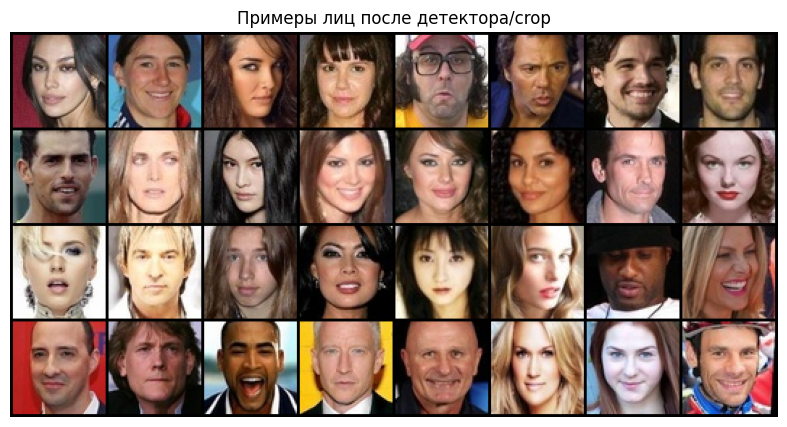

In [ ]:
def show_crops_grid(crop_dir: Path, n: int = 32):
    paths = sorted(crop_dir.glob("*.jpg"))
    assert len(paths) > 0, "Нет crop-файлов."
    sample = random.sample(paths, min(n, len(paths)))

    imgs = []
    for p in sample:
        img = Image.open(p).convert("RGB")
        tensor = T.ToTensor()(img)
        imgs.append(tensor)

    grid = make_grid(torch.stack(imgs), nrow=8)
    plt.figure(figsize=(10, 5))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    plt.title("Примеры лиц после детектора/crop")
    plt.show()

show_crops_grid(cfg.crop_dir, n=32)

## 3. Dataset и DataLoader

На этом этапе crop-файлы превращаются в PyTorch dataset. Важные детали:

- изображения нормализуются в диапазон `[-1, 1]`, потому что генератор заканчивается `Tanh`;
- атрибут CelebA `-1 / 1` переводится в класс `0 / 1`, чтобы его можно было использовать как label;
- `RandomHorizontalFlip` включён как безопасная аугментация: зеркальный поворот лица не меняет пол и обычно улучшает разнообразие обучающих примеров;
- `drop_last=True` оставляет одинаковый размер батчей, что делает обучение GAN стабильнее.

Один и тот же DataLoader используется для безусловного и условного обучения. Для безусловной модели labels игнорируются, а для conditional WGAN-GP подаются в генератор и critic.


In [10]:
class CroppedCelebADataset(Dataset):
    def __init__(
        self,
        crop_dir: Path,
        labels_csv: Path,
        attr_name: str = "Male",
        transform=None,
        max_items: Optional[int] = None,
        balanced: bool = False,
        seed: int = 42,
    ):
        self.crop_dir = Path(crop_dir)
        self.attr_name = attr_name
        self.transform = transform

        df = pd.read_csv(labels_csv)
        df = df[df["image_id"].apply(lambda x: (self.crop_dir / x).exists())].copy()

        if balanced:
            df0 = df[df[attr_name] == -1]
            df1 = df[df[attr_name] == 1]
            n = min(len(df0), len(df1))
            df0 = df0.sample(n, random_state=seed)
            df1 = df1.sample(n, random_state=seed)
            df = pd.concat([df0, df1], ignore_index=True)
            df = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)

        if max_items is not None and len(df) > max_items:
            df = df.sample(max_items, random_state=seed).reset_index(drop=True)

        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.crop_dir / row["image_id"]
        img = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        # CelebA: 1 = признак есть, -1 = признака нет.
        label = 1 if int(row[self.attr_name]) == 1 else 0
        return img, torch.tensor(label, dtype=torch.long)

train_transforms = [
    T.Resize((cfg.image_size, cfg.image_size)),
]
if cfg.use_horizontal_flip:
    train_transforms.append(T.RandomHorizontalFlip(p=0.5))
train_transforms.extend([
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])
transform = T.Compose(train_transforms)

dataset = CroppedCelebADataset(
    crop_dir=cfg.crop_dir,
    labels_csv=cfg.labels_csv,
    attr_name=cfg.attr_name,
    transform=transform,
    max_items=cfg.train_max_images,
    balanced=cfg.use_balanced_dataset,
    seed=SEED,
)

loader = DataLoader(
    dataset,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=True,
    drop_last=True,
)

print("Dataset size:", len(dataset))
print("Batches:", len(loader))
print("Labels:", dataset.df[cfg.attr_name].value_counts().to_dict())

real_batch, label_batch = next(iter(loader))
print(real_batch.shape, real_batch.min().item(), real_batch.max().item(), label_batch[:10])


Dataset size: 79963
Batches: 624
Labels: {-1: 46464, 1: 33499}
torch.Size([128, 3, 64, 64]) -1.0 1.0 tensor([1, 0, 0, 1, 0, 1, 1, 1, 1, 1])


## 4. Архитектура WGAN-GP

**Generator** получает случайный вектор `z` размера `z_dim` и постепенно увеличивает spatial resolution через `ConvTranspose2d`: `4×4 → 8×8 → 16×16 → 32×32 → 64×64`. Последний слой `Tanh` выдаёт изображение в диапазоне `[-1, 1]`.

**Critic** делает обратное: принимает изображение `64×64`, сворачивает его до признакового вектора и выдаёт один score. Важно: у critic нет `Sigmoid`, потому что это не классификатор вероятности real/fake.

Для conditional версии используется простая и устойчивая схема:

- в generator label embedding добавляется к latent-вектору `z`;
- в critic используется projection conditioning: к score добавляется скалярное произведение признаков изображения и embedding label.

Такую conditional модель удобно инициализировать весами безусловной модели: общие convolution/linear слои совпадают по shape, а новые embedding-слои обучаются с нуля.


In [11]:
def weights_init(m):
    classname = m.__class__.__name__
    if "Conv" in classname or "Linear" in classname:
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 0.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            nn.init.constant_(m.bias.data, 0)
    elif "BatchNorm" in classname:
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 1.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            nn.init.constant_(m.bias.data, 0)

class Generator(nn.Module):
    def __init__(
        self,
        z_dim: int = 128,
        img_channels: int = 3,
        features_g: int = 64,
        n_classes: Optional[int] = None,
    ):
        super().__init__()
        self.z_dim = z_dim
        self.n_classes = n_classes
        self.label_emb = nn.Embedding(n_classes, z_dim) if n_classes is not None else None

        self.project = nn.Sequential(
            nn.Linear(z_dim, features_g * 8 * 4 * 4),
            nn.BatchNorm1d(features_g * 8 * 4 * 4),
            nn.ReLU(True),
        )

        self.net = nn.Sequential(
            # 4x4 -> 8x8
            nn.ConvTranspose2d(features_g * 8, features_g * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g * 4),
            nn.ReLU(True),

            # 8x8 -> 16x16
            nn.ConvTranspose2d(features_g * 4, features_g * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g * 2),
            nn.ReLU(True),

            # 16x16 -> 32x32
            nn.ConvTranspose2d(features_g * 2, features_g, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g),
            nn.ReLU(True),

            # 32x32 -> 64x64
            nn.ConvTranspose2d(features_g, img_channels, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z: torch.Tensor, labels: Optional[torch.Tensor] = None) -> torch.Tensor:
        if self.label_emb is not None:
            if labels is None:
                raise ValueError("Conditional Generator needs labels.")
            z = z + self.label_emb(labels)

        x = self.project(z)
        x = x.view(z.size(0), -1, 4, 4)
        return self.net(x)

class Critic(nn.Module):
    def __init__(
        self,
        img_channels: int = 3,
        features_d: int = 64,
        n_classes: Optional[int] = None,
    ):
        super().__init__()
        self.n_classes = n_classes

        self.features = nn.Sequential(
            # 64x64 -> 32x32
            nn.Conv2d(img_channels, features_d, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            # 32x32 -> 16x16
            nn.Conv2d(features_d, features_d * 2, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            # 16x16 -> 8x8
            nn.Conv2d(features_d * 2, features_d * 4, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            # 8x8 -> 4x4
            nn.Conv2d(features_d * 4, features_d * 8, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.feature_dim = features_d * 8 * 4 * 4
        self.out = nn.Linear(self.feature_dim, 1)
        self.label_emb = nn.Embedding(n_classes, self.feature_dim) if n_classes is not None else None

    def forward(self, x: torch.Tensor, labels: Optional[torch.Tensor] = None) -> torch.Tensor:
        feat = self.features(x).view(x.size(0), -1)
        score = self.out(feat).view(-1)

        if self.label_emb is not None:
            if labels is None:
                raise ValueError("Conditional Critic needs labels.")
            emb = self.label_emb(labels)

            score = score + torch.sum(feat * emb, dim=1) / math.sqrt(feat.size(1))

        return score

G_test = Generator(cfg.z_dim, features_g=cfg.g_features).to(DEVICE)
D_test = Critic(features_d=cfg.d_features).to(DEVICE)
z = torch.randn(4, cfg.z_dim, device=DEVICE)
print("G output:", G_test(z).shape)
print("D output:", D_test(G_test(z)).shape)

del G_test, D_test
torch.cuda.empty_cache()

G output: torch.Size([4, 3, 64, 64])
D output: torch.Size([4])


## 5. Функции обучения WGAN-GP

В WGAN-GP critic обучается чаще генератора: параметр `n_critic=5` означает, что на несколько шагов critic приходится один шаг generator. Это нужно, чтобы critic успевал давать генератору осмысленный градиент.

Основные величины, которые логируются:

- `real_score = D(real).mean()` — средняя оценка реальных изображений;
- `fake_score = D(fake).mean()` — средняя оценка сгенерированных изображений;
- `wasserstein_est = real_score - fake_score` — текущая оценка разрыва между real и fake;
- `gradient_penalty` — штраф за нарушение Lipschitz-ограничения;
- `critic_loss = -wasserstein_est + lambda_gp * gradient_penalty`;
- `generator_loss = -D(fake).mean()`.

Отрицательные значения `critic_loss` и большие отрицательные значения `generator_loss` для WGAN-GP не являются ошибкой. Их нужно интерпретировать вместе с `wasserstein_est`, `gradient_penalty`, FID/IS и визуальными сэмплами.

Дополнительно включён **EMA генератора**. После каждого шага generator создаётся экспоненциально сглаженная версия его весов. Для сохранения картинок и метрик чаще лучше использовать EMA-модель: она менее шумная и обычно даёт более чистые лица.


In [12]:
import copy

def to_device_labels(labels: torch.Tensor, conditional: bool) -> Optional[torch.Tensor]:
    return labels.to(DEVICE, non_blocking=True) if conditional else None

def gradient_penalty(
    critic: nn.Module,
    real: torch.Tensor,
    fake: torch.Tensor,
    labels: Optional[torch.Tensor] = None,
) -> torch.Tensor:
    batch_size = real.size(0)
    epsilon = torch.rand(batch_size, 1, 1, 1, device=real.device)
    mixed = epsilon * real + (1.0 - epsilon) * fake
    mixed.requires_grad_(True)

    mixed_scores = critic(mixed, labels)
    grad_outputs = torch.ones_like(mixed_scores, device=real.device)

    gradients = torch.autograd.grad(
        outputs=mixed_scores,
        inputs=mixed,
        grad_outputs=grad_outputs,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]

    gradients = gradients.view(batch_size, -1)
    gp = ((gradients.norm(2, dim=1) - 1.0) ** 2).mean()
    return gp

@torch.no_grad()
def make_ema_model(model: nn.Module) -> nn.Module:
    ema_model = copy.deepcopy(model).to(DEVICE)
    ema_model.eval()
    for p in ema_model.parameters():
        p.requires_grad_(False)
    return ema_model

@torch.no_grad()
def update_ema_model(ema_model: nn.Module, model: nn.Module, decay: float = 0.999):
    ema_state = ema_model.state_dict()
    model_state = model.state_dict()
    for key, ema_value in ema_state.items():
        model_value = model_state[key].detach()
        if torch.is_floating_point(ema_value):
            ema_value.copy_(ema_value * decay + model_value * (1.0 - decay))
        else:
            ema_value.copy_(model_value)

@torch.no_grad()
def save_samples(
    generator: nn.Module,
    fixed_noise: torch.Tensor,
    out_path: Path,
    fixed_labels: Optional[torch.Tensor] = None,
    nrow: int = 8,
):
    was_training = generator.training
    generator.eval()
    fake = generator(fixed_noise, fixed_labels)
    grid = make_grid(fake, nrow=nrow, normalize=True, value_range=(-1, 1))
    out_path.parent.mkdir(parents=True, exist_ok=True)
    save_image(grid, out_path)
    generator.train(was_training)

def plot_history(history_csv: Path, title: str):
    hist = pd.read_csv(history_csv)
    display(hist.tail())

    plt.figure(figsize=(10, 5))
    if "critic_loss" in hist:
        plt.plot(hist["epoch"], hist["critic_loss"], label="critic_loss")
    if "generator_loss" in hist:
        plt.plot(hist["epoch"], hist["generator_loss"], label="generator_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + ": losses")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 5))
    if "wasserstein_est" in hist:
        plt.plot(hist["epoch"], hist["wasserstein_est"], label="wasserstein_est")
    if "gradient_penalty" in hist:
        plt.plot(hist["epoch"], hist["gradient_penalty"], label="gradient_penalty")
    plt.xlabel("epoch")
    plt.ylabel("value")
    plt.title(title + ": WGAN-GP diagnostics")
    plt.legend()
    plt.grid(True)
    plt.show()

    if {"real_score", "fake_score"}.issubset(hist.columns):
        plt.figure(figsize=(10, 5))
        plt.plot(hist["epoch"], hist["real_score"], label="D(real)")
        plt.plot(hist["epoch"], hist["fake_score"], label="D(fake)")
        plt.xlabel("epoch")
        plt.ylabel("critic score")
        plt.title(title + ": critic scores")
        plt.legend()
        plt.grid(True)
        plt.show()

def save_checkpoint(
    out_dir: Path,
    generator: nn.Module,
    critic: nn.Module,
    opt_g,
    opt_d,
    epoch: int,
    history: List[Dict],
    name: str = "last",
    generator_ema: Optional[nn.Module] = None,
    ema_decay: Optional[float] = None,
):
    out_dir.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "epoch": epoch,
            "model": generator.state_dict(),
            "optimizer": opt_g.state_dict(),
            "history": history,
        },
        out_dir / f"G_{name}.pt"
    )
    torch.save(
        {
            "epoch": epoch,
            "model": critic.state_dict(),
            "optimizer": opt_d.state_dict(),
            "history": history,
        },
        out_dir / f"D_{name}.pt"
    )
    if generator_ema is not None:
        torch.save(
            {
                "epoch": epoch,
                "model": generator_ema.state_dict(),
                "history": history,
                "ema_decay": ema_decay,
            },
            out_dir / f"G_ema_{name}.pt"
        )

def load_compatible_weights(model: nn.Module, checkpoint_path: Path) -> int:
    """Загрузка совместимых весов. Нужна для переноса unconditional -> conditional."""
    ckpt = torch.load(checkpoint_path, map_location=DEVICE)
    state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt

    current = model.state_dict()
    compatible = {}
    for k, v in state.items():
        if k in current and current[k].shape == v.shape:
            compatible[k] = v

    current.update(compatible)
    model.load_state_dict(current)
    print(f"Loaded compatible tensors: {len(compatible)} / {len(current)} from {checkpoint_path}")
    return len(compatible)

def train_wgan_gp(
    generator: nn.Module,
    critic: nn.Module,
    loader: DataLoader,
    epochs: int,
    out_dir: Path,
    conditional: bool = False,
    z_dim: int = 128,
    lr: float = 1e-4,
    beta1: float = 0.0,
    beta2: float = 0.9,
    lambda_gp: float = 10.0,
    n_critic: int = 5,
    resume: bool = False,
    sample_every: int = 1,
    checkpoint_every: int = 1,
    use_ema: bool = True,
    ema_decay: float = 0.999,
) -> Tuple[nn.Module, nn.Module, pd.DataFrame, Optional[nn.Module]]:
    out_dir.mkdir(parents=True, exist_ok=True)
    samples_dir = out_dir / "samples"
    samples_dir.mkdir(exist_ok=True)

    generator = generator.to(DEVICE)
    critic = critic.to(DEVICE)

    opt_g = optim.Adam(generator.parameters(), lr=lr, betas=(beta1, beta2))
    opt_d = optim.Adam(critic.parameters(), lr=lr, betas=(beta1, beta2))

    start_epoch = 1
    history: List[Dict] = []

    if resume and (out_dir / "G_last.pt").exists() and (out_dir / "D_last.pt").exists():
        g_ckpt = torch.load(out_dir / "G_last.pt", map_location=DEVICE)
        d_ckpt = torch.load(out_dir / "D_last.pt", map_location=DEVICE)
        generator.load_state_dict(g_ckpt["model"])
        critic.load_state_dict(d_ckpt["model"])
        opt_g.load_state_dict(g_ckpt["optimizer"])
        opt_d.load_state_dict(d_ckpt["optimizer"])
        history = g_ckpt.get("history", [])
        start_epoch = int(g_ckpt["epoch"]) + 1
        print(f"Resumed from epoch {start_epoch - 1}")

    generator_ema = make_ema_model(generator) if use_ema else None
    if generator_ema is not None and resume and (out_dir / "G_ema_last.pt").exists():
        ema_ckpt = torch.load(out_dir / "G_ema_last.pt", map_location=DEVICE)
        generator_ema.load_state_dict(ema_ckpt["model"])
        print("Loaded EMA generator checkpoint")

    fixed_noise = torch.randn(64, z_dim, device=DEVICE)
    if conditional:
        fixed_labels = torch.tensor([0] * 32 + [1] * 32, device=DEVICE, dtype=torch.long)
    else:
        fixed_labels = None

    sample_every = max(1, int(sample_every))
    checkpoint_every = max(1, int(checkpoint_every))

    for epoch in range(start_epoch, epochs + 1):
        generator.train()
        critic.train()
        if generator_ema is not None:
            generator_ema.eval()

        critic_losses = []
        gen_losses = []
        wasserstein_values = []
        gp_values = []
        real_score_values = []
        fake_score_values = []

        pbar = tqdm(loader, desc=f"Epoch {epoch}/{epochs}")
        for batch_idx, (real, labels) in enumerate(pbar):
            real = real.to(DEVICE, non_blocking=True)
            labels_for_model = to_device_labels(labels, conditional)
            bs = real.size(0)

            # --- Train Critic ---
            z = torch.randn(bs, z_dim, device=DEVICE)
            fake = generator(z, labels_for_model)

            critic_real_score = critic(real, labels_for_model)
            critic_fake_score = critic(fake.detach(), labels_for_model)
            critic_real = critic_real_score.mean()
            critic_fake = critic_fake_score.mean()
            gp = gradient_penalty(critic, real, fake.detach(), labels_for_model)

            wasserstein_est = critic_real - critic_fake
            critic_loss = -wasserstein_est + lambda_gp * gp

            opt_d.zero_grad(set_to_none=True)
            critic_loss.backward()
            opt_d.step()

            critic_losses.append(float(critic_loss.detach().cpu()))
            wasserstein_values.append(float(wasserstein_est.detach().cpu()))
            gp_values.append(float(gp.detach().cpu()))
            real_score_values.append(float(critic_real.detach().cpu()))
            fake_score_values.append(float(critic_fake.detach().cpu()))

            # --- Train Generator ---
            if batch_idx % n_critic == 0:
                z = torch.randn(bs, z_dim, device=DEVICE)
                fake = generator(z, labels_for_model)
                gen_loss = -critic(fake, labels_for_model).mean()

                opt_g.zero_grad(set_to_none=True)
                gen_loss.backward()
                opt_g.step()

                if generator_ema is not None:
                    update_ema_model(generator_ema, generator, decay=ema_decay)

                gen_losses.append(float(gen_loss.detach().cpu()))

            pbar.set_postfix({
                "D": np.mean(critic_losses[-20:]) if critic_losses else 0.0,
                "G": np.mean(gen_losses[-20:]) if gen_losses else 0.0,
                "W": np.mean(wasserstein_values[-20:]) if wasserstein_values else 0.0,
                "GP": np.mean(gp_values[-20:]) if gp_values else 0.0,
            })

        row = {
            "epoch": epoch,
            "critic_loss": float(np.mean(critic_losses)),
            "generator_loss": float(np.mean(gen_losses)) if gen_losses else np.nan,
            "wasserstein_est": float(np.mean(wasserstein_values)),
            "gradient_penalty": float(np.mean(gp_values)),
            "real_score": float(np.mean(real_score_values)),
            "fake_score": float(np.mean(fake_score_values)),
        }
        history.append(row)

        history_df = pd.DataFrame(history)
        history_df.to_csv(out_dir / "history.csv", index=False)

        sample_model = generator_ema if generator_ema is not None else generator
        if epoch % sample_every == 0 or epoch == epochs:
            save_samples(
                sample_model,
                fixed_noise,
                samples_dir / f"epoch_{epoch:03d}.png",
                fixed_labels=fixed_labels,
                nrow=8,
            )

        if epoch % checkpoint_every == 0 or epoch == epochs:
            save_checkpoint(
                out_dir=out_dir,
                generator=generator,
                critic=critic,
                opt_g=opt_g,
                opt_d=opt_d,
                epoch=epoch,
                history=history,
                name="last",
                generator_ema=generator_ema,
                ema_decay=ema_decay,
            )

        print(row)

    return generator, critic, pd.DataFrame(history), generator_ema


## 6. Безусловная генерация: WGAN-GP

Сначала обучается безусловная модель: генератор получает только шум `z`, без информации о поле или другом атрибуте. Это нужно по двум причинам.

Во-первых, это самостоятельная часть задания: модель должна научиться генерировать лица из распределения CelebA. Во-вторых, после такого обучения у нас появляются полезные convolution-признаки и в generator, и в critic. Затем conditional модель стартует не с нуля, а с этих весов, что обычно ускоряет обучение и улучшает стабильность.

По умолчанию включён `resume_training=True`, поэтому если Colab оборвётся, повторный запуск продолжит обучение с `G_last.pt`, `D_last.pt` и `G_ema_last.pt`.


Epoch 1/40:   0%|          | 0/624 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


{'epoch': 1, 'critic_loss': -49.494146298139526, 'generator_loss': -48.19067272018269, 'wasserstein_est': 71.45393085532272, 'gradient_penalty': 2.19597845050269, 'real_score': 121.5595157862826, 'fake_score': 50.105584997096464}


Epoch 2/40:   0%|          | 0/624 [00:00<?, ?it/s]

{'epoch': 2, 'critic_loss': -13.975906704862913, 'generator_loss': -41.41690231323242, 'wasserstein_est': 17.121298282574383, 'gradient_penalty': 0.31453916100928414, 'real_score': 60.943566566858536, 'fake_score': 43.82226828428415}


...

Epoch 39/40:   0%|          | 0/624 [00:00<?, ?it/s]

{'epoch': 39, 'critic_loss': -4.583162854879331, 'generator_loss': 3.7669792162701485, 'wasserstein_est': 5.073670740693044, 'gradient_penalty': 0.04905078742796412, 'real_score': 1.8095387000327883, 'fake_score': -3.2641320379080776}


Epoch 40/40:   0%|          | 0/624 [00:00<?, ?it/s]

{'epoch': 40, 'critic_loss': -4.524794722214724, 'generator_loss': 3.4461248153448105, 'wasserstein_est': 5.00301856184617, 'gradient_penalty': 0.047822383062269255, 'real_score': 1.8487471897208776, 'fake_score': -3.1542713697522116}
Using EMA for unconditional samples/metrics: True


,epoch,critic_loss,generator_loss,wasserstein_est,gradient_penalty,real_score,fake_score
35,36,-4.747042,4.533980,5.262285,0.051524,1.215024,-4.047261
36,37,-4.689971,4.149104,5.196989,0.050702,1.322582,-3.874407
37,38,-4.638330,3.812383,5.138760,0.050043,1.940686,-3.198073
38,39,-4.583163,3.766979,5.073671,0.049051,1.809539,-3.264132
39,40,-4.524795,3.446125,5.003019,0.047822,1.848747,-3.154271


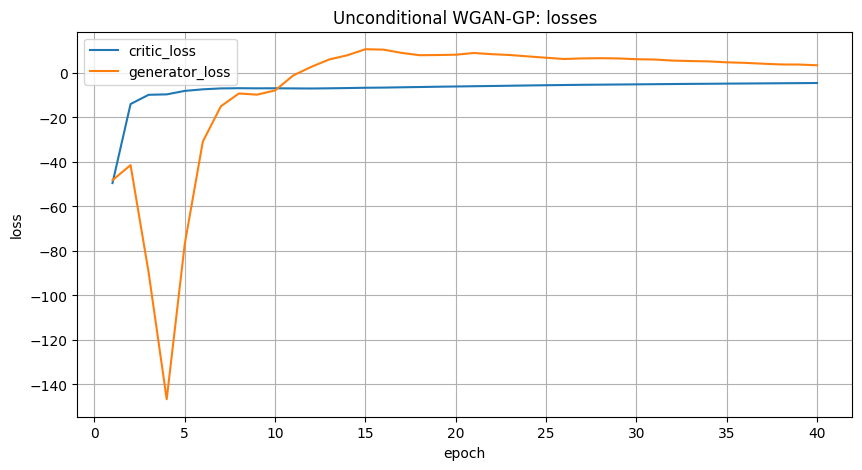

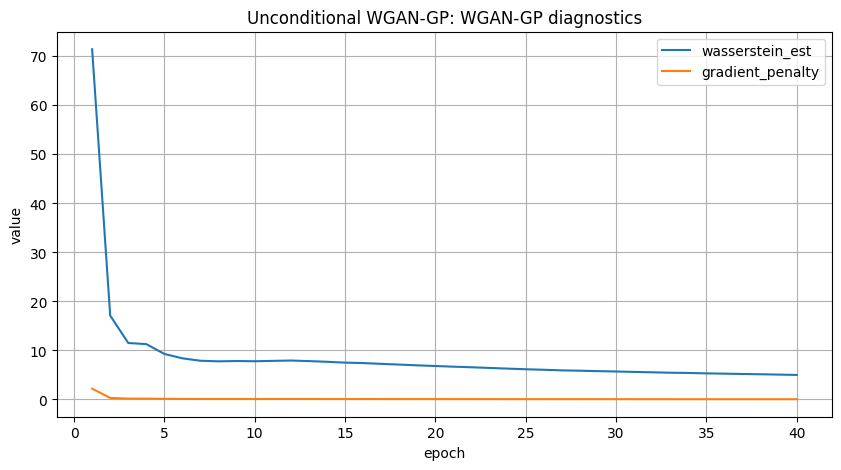

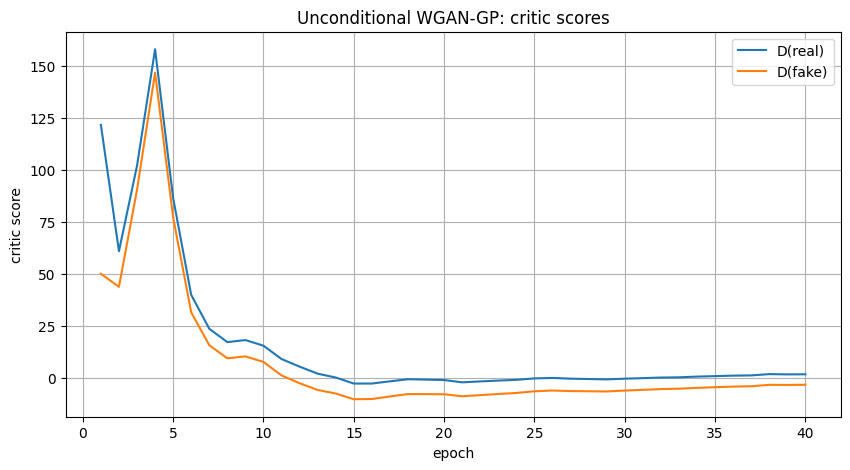

In [13]:
# Обучение unconditional WGAN-GP

uncond_dir = cfg.runs_dir / "unconditional_wgan_gp"

G_uncond = Generator(
    z_dim=cfg.z_dim,
    features_g=cfg.g_features,
    n_classes=None,
).to(DEVICE)

D_uncond = Critic(
    features_d=cfg.d_features,
    n_classes=None,
).to(DEVICE)

G_uncond.apply(weights_init)
D_uncond.apply(weights_init)

G_uncond, D_uncond, hist_uncond, G_uncond_ema = train_wgan_gp(
    generator=G_uncond,
    critic=D_uncond,
    loader=loader,
    epochs=cfg.epochs_uncond,
    out_dir=uncond_dir,
    conditional=False,
    z_dim=cfg.z_dim,
    lr=cfg.lr,
    beta1=cfg.beta1,
    beta2=cfg.beta2,
    lambda_gp=cfg.lambda_gp,
    n_critic=cfg.n_critic,
    resume=cfg.resume_training,
    sample_every=cfg.sample_every,
    checkpoint_every=cfg.checkpoint_every,
    use_ema=cfg.use_ema,
    ema_decay=cfg.ema_decay,
)

G_uncond_eval = G_uncond_ema if (cfg.use_ema_for_eval and G_uncond_ema is not None) else G_uncond
print("Using EMA for unconditional samples/metrics:", G_uncond_eval is G_uncond_ema)

plot_history(uncond_dir / "history.csv", "Unconditional WGAN-GP")


/content/celeba_lab4/runs/unconditional_wgan_gp/samples/epoch_040.png


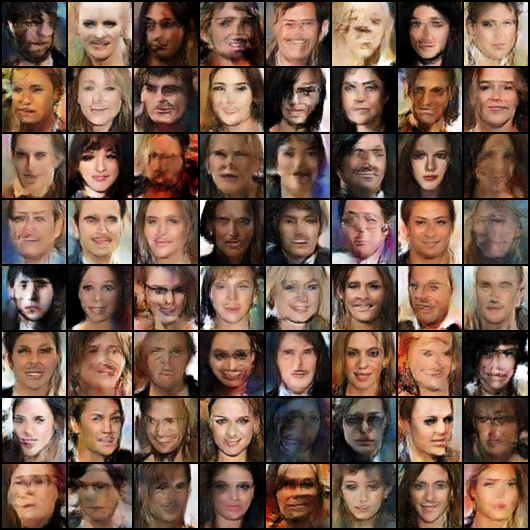

In [14]:
# Показ последней сетки unconditional генерации.
# Если cfg.use_ema=True, эти сэмплы сохранены EMA-версией генератора.

from IPython.display import display

last_sample = sorted((uncond_dir / "samples").glob("*.png"))[-1]
print(last_sample)
display(Image.open(last_sample))


## 7. Преобразование в условную сеть и обучение Conditional WGAN-GP

Теперь добавляем условие `label`: в этом ноутбуке используется признак CelebA `Male`.

Модель меняется минимально:

- в **generator** появляется embedding класса, который добавляется к latent-вектору `z`;
- в **critic** появляется projection term, который связывает признаки изображения с embedding класса.

После создания conditional моделей загружаются все совместимые веса из unconditional модели. Новые embedding-слои не имеют соответствий по shape, поэтому они остаются случайно инициализированными и обучаются на conditional этапе.

Для переноса generator при наличии EMA используется `G_ema_last.pt`, потому что именно он обычно даёт более гладкие веса. Critic переносится из обычного `D_last.pt`.


Generator transfer checkpoint: /content/celeba_lab4/runs/unconditional_wgan_gp/G_ema_last.pt
Loaded compatible tensors: 26 / 27 from /content/celeba_lab4/runs/unconditional_wgan_gp/G_ema_last.pt
Loaded compatible tensors: 10 / 11 from /content/celeba_lab4/runs/unconditional_wgan_gp/D_last.pt


Epoch 1/25:   0%|          | 0/624 [00:00<?, ?it/s]

{'epoch': 1, 'critic_loss': -6.0585344066986675, 'generator_loss': 3.916434991121292, 'wasserstein_est': 6.833520345962965, 'gradient_penalty': 0.07749859317659567, 'real_score': 3.2028043187963657, 'fake_score': -3.630716033297806}


Epoch 2/25:   0%|          | 0/624 [00:00<?, ?it/s]

{'epoch': 2, 'critic_loss': -5.712073823580375, 'generator_loss': 3.6410013150721787, 'wasserstein_est': 6.421333027191651, 'gradient_penalty': 0.07092592056291416, 'real_score': 3.218675615439096, 'fake_score': -3.202657414271902}


...

Epoch 24/25:   0%|          | 0/624 [00:00<?, ?it/s]

{'epoch': 24, 'critic_loss': -3.9911141166320214, 'generator_loss': 2.335048455685377, 'wasserstein_est': 4.388353346632077, 'gradient_penalty': 0.039723922800010025, 'real_score': 2.4646619447829345, 'fake_score': -1.9236914053863774}


Epoch 25/25:   0%|          | 0/624 [00:00<?, ?it/s]

{'epoch': 25, 'critic_loss': -3.94620542992384, 'generator_loss': 2.1905589549541475, 'wasserstein_est': 4.3369460224341125, 'gradient_penalty': 0.03907405915490996, 'real_score': 2.4150417055218267, 'fake_score': -1.9219043202346}
Using EMA for conditional samples/metrics: True


,epoch,critic_loss,generator_loss,wasserstein_est,gradient_penalty,real_score,fake_score
20,21,-4.100262,2.818256,4.516401,0.041614,2.189072,-2.327329
21,22,-4.061022,2.504480,4.470170,0.040915,2.131332,-2.338837
22,23,-4.020963,2.423350,4.422277,0.040131,2.260317,-2.161959
23,24,-3.991114,2.335048,4.388353,0.039724,2.464662,-1.923691
24,25,-3.946205,2.190559,4.336946,0.039074,2.415042,-1.921904


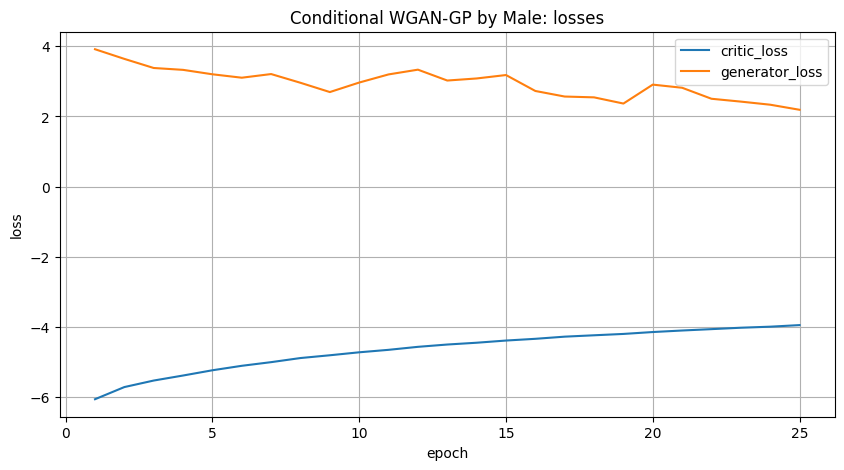

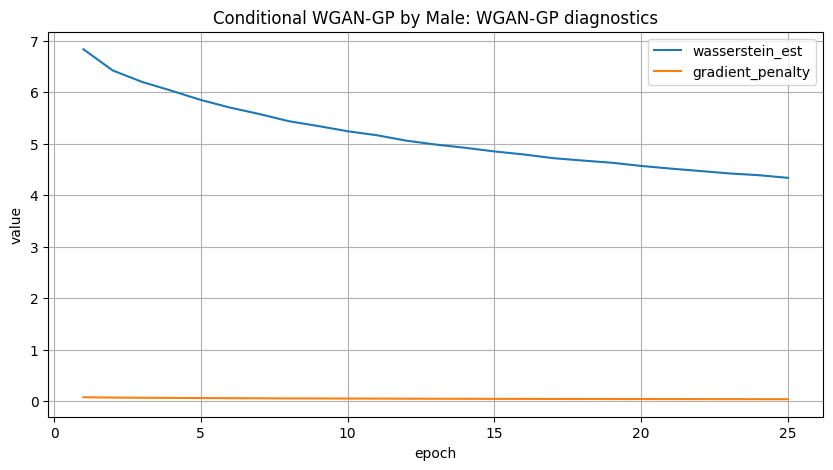

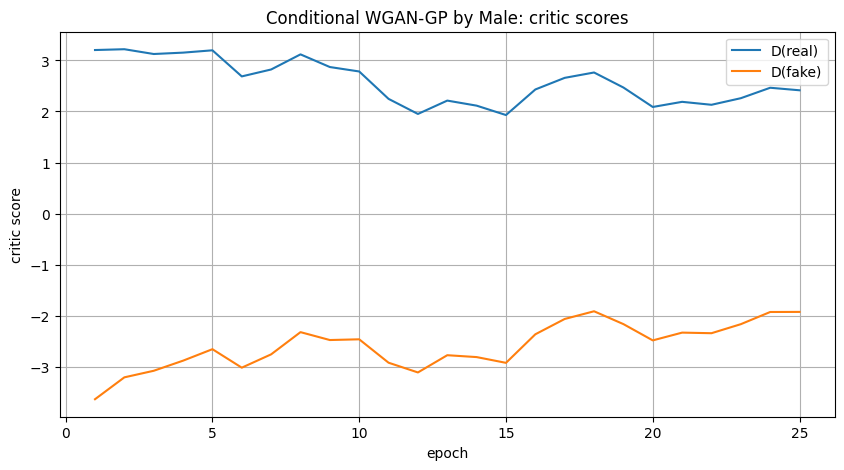

In [15]:
# Conditional WGAN-GP с переносом весов из unconditional модели

cond_dir = cfg.runs_dir / f"conditional_wgan_gp_{cfg.attr_name.lower()}"

G_cond = Generator(
    z_dim=cfg.z_dim,
    features_g=cfg.g_features,
    n_classes=cfg.n_classes,
).to(DEVICE)

D_cond = Critic(
    features_d=cfg.d_features,
    n_classes=cfg.n_classes,
).to(DEVICE)

G_cond.apply(weights_init)
D_cond.apply(weights_init)

# Переносим совместимые слои из безусловной модели.
g_transfer_ckpt = uncond_dir / "G_ema_last.pt" if (cfg.use_ema and (uncond_dir / "G_ema_last.pt").exists()) else uncond_dir / "G_last.pt"
print("Generator transfer checkpoint:", g_transfer_ckpt)
load_compatible_weights(G_cond, g_transfer_ckpt)
load_compatible_weights(D_cond, uncond_dir / "D_last.pt")

G_cond, D_cond, hist_cond, G_cond_ema = train_wgan_gp(
    generator=G_cond,
    critic=D_cond,
    loader=loader,
    epochs=cfg.epochs_cond,
    out_dir=cond_dir,
    conditional=True,
    z_dim=cfg.z_dim,
    lr=cfg.lr,
    beta1=cfg.beta1,
    beta2=cfg.beta2,
    lambda_gp=cfg.lambda_gp,
    n_critic=cfg.n_critic,
    resume=cfg.resume_training,
    sample_every=cfg.sample_every,
    checkpoint_every=cfg.checkpoint_every,
    use_ema=cfg.use_ema,
    ema_decay=cfg.ema_decay,
)

G_cond_eval = G_cond_ema if (cfg.use_ema_for_eval and G_cond_ema is not None) else G_cond
print("Using EMA for conditional samples/metrics:", G_cond_eval is G_cond_ema)

plot_history(cond_dir / "history.csv", f"Conditional WGAN-GP by {cfg.attr_name}")


/content/celeba_lab4/runs/conditional_wgan_gp_male/samples/epoch_025.png


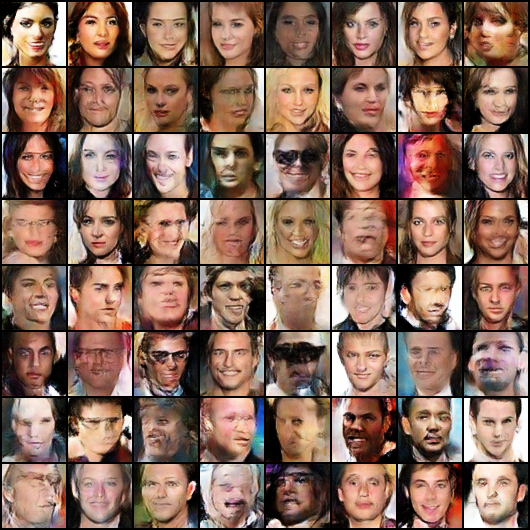

In [ ]:
# Первые 32 изображения: label=0, вторые 32: label=1.
# Для attr_name="Male": label=0 означает not Male, label=1 означает Male.

last_cond_sample = sorted((cond_dir / "samples").glob("*.png"))[-1]
print(last_cond_sample)
display(Image.open(last_cond_sample))


label 0: /content/celeba_lab4/runs/conditional_wgan_gp_male/samples/label_0_grid.png


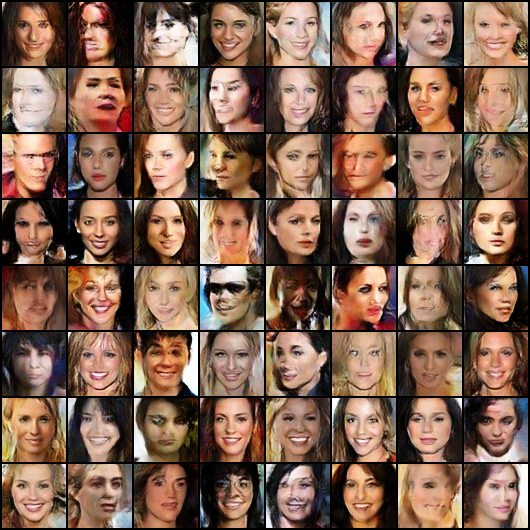

label 1: /content/celeba_lab4/runs/conditional_wgan_gp_male/samples/label_1_grid.png


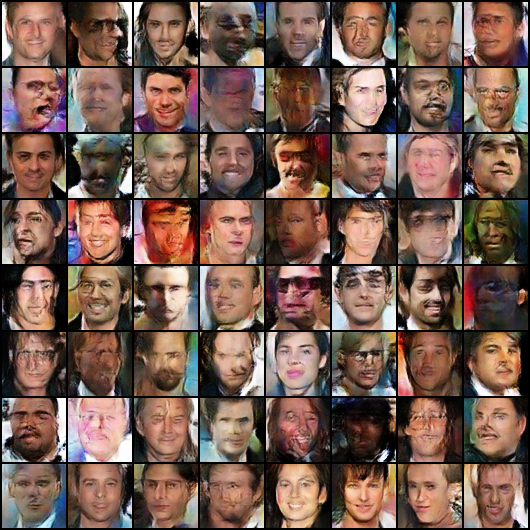

In [17]:
# Генерация отдельных сеток для label=0 и label=1.
# Используем G_cond_eval: это EMA-модель, если cfg.use_ema_for_eval=True.

@torch.no_grad()
def generate_label_grid(generator: nn.Module, label: int, out_path: Path, n: int = 64, nrow: int = 8):
    was_training = generator.training
    generator.eval()
    z = torch.randn(n, cfg.z_dim, device=DEVICE)
    labels = torch.full((n,), label, dtype=torch.long, device=DEVICE)
    fake = generator(z, labels)
    grid = make_grid(fake, nrow=nrow, normalize=True, value_range=(-1, 1))
    out_path.parent.mkdir(parents=True, exist_ok=True)
    save_image(grid, out_path)
    generator.train(was_training)
    return out_path

label0_path = generate_label_grid(G_cond_eval, 0, cond_dir / "samples" / "label_0_grid.png")
label1_path = generate_label_grid(G_cond_eval, 1, cond_dir / "samples" / "label_1_grid.png")

print("label 0:", label0_path)
display(Image.open(label0_path))

print("label 1:", label1_path)
display(Image.open(label1_path))


## 8. Метрики: FID и Inception Score

Для GAN одних loss-кривых недостаточно, поэтому считаются две стандартные метрики.

**FID** сравнивает распределения признаков реальных и сгенерированных изображений в пространстве Inception-сети. Чем FID ниже, тем ближе сгенерированное распределение к реальному. Это главная метрика качества в отчёте.

**Inception Score** оценивает, насколько изображения одновременно разнообразны и уверенно распознаются Inception-моделью. Чем IS выше, тем лучше, но для лиц эта метрика менее информативна, чем FID, потому что Inception обучался на ImageNet, а не специально на лицах.

Для более честной оценки используется `cfg.eval_samples=10000`. Если Colab ограничен по времени, можно поставить `1000-5000`, но метрики будут шумнее.


In [18]:
# Метрики FID и IS через torchmetrics.
# Первый запуск может скачать веса Inception.

from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore

def tensor_to_uint8(x: torch.Tensor) -> torch.Tensor:
    # x в диапазоне [-1, 1] -> uint8 [0, 255]
    x = (x.detach() * 0.5 + 0.5).clamp(0, 1)
    return (x * 255).to(torch.uint8)

@torch.no_grad()
def evaluate_fid_is(
    generator: nn.Module,
    loader: DataLoader,
    n_samples: int = 5000,
    conditional: bool = False,
    z_dim: int = 128,
    n_classes: int = 2,
) -> Dict[str, float]:
    generator.eval()

    fid = FrechetInceptionDistance(feature=2048, normalize=False).to(DEVICE)
    inception = InceptionScore(normalize=False).to(DEVICE)

    total = 0
    loader_iter = iter(loader)

    pbar = tqdm(total=n_samples, desc="Evaluating FID/IS")
    while total < n_samples:
        try:
            real, labels = next(loader_iter)
        except StopIteration:
            loader_iter = iter(loader)
            real, labels = next(loader_iter)

        bs = min(real.size(0), n_samples - total)
        real = real[:bs].to(DEVICE, non_blocking=True)
        labels = labels[:bs].to(DEVICE, non_blocking=True)

        z = torch.randn(bs, z_dim, device=DEVICE)
        if conditional:
            fake = generator(z, labels)
        else:
            fake = generator(z)

        real_uint8 = tensor_to_uint8(real)
        fake_uint8 = tensor_to_uint8(fake)

        fid.update(real_uint8, real=True)
        fid.update(fake_uint8, real=False)
        inception.update(fake_uint8)

        total += bs
        pbar.update(bs)

    pbar.close()

    fid_score = float(fid.compute().detach().cpu())
    is_mean, is_std = inception.compute()

    return {
        "FID": fid_score,
        "IS_mean": float(is_mean.detach().cpu()),
        "IS_std": float(is_std.detach().cpu()),
        "n_samples": int(n_samples),
    }

G_uncond_for_metrics = G_uncond_eval if "G_uncond_eval" in globals() else G_uncond
G_cond_for_metrics = G_cond_eval if "G_cond_eval" in globals() else G_cond

metrics_uncond = evaluate_fid_is(
    G_uncond_for_metrics,
    loader,
    n_samples=cfg.eval_samples,
    conditional=False,
    z_dim=cfg.z_dim,
)

metrics_cond = evaluate_fid_is(
    G_cond_for_metrics,
    loader,
    n_samples=cfg.eval_samples,
    conditional=True,
    z_dim=cfg.z_dim,
)

metrics_df = pd.DataFrame([
    {"model": "unconditional_wgan_gp", "eval_generator": "EMA" if G_uncond_for_metrics is G_uncond_ema else "raw", **metrics_uncond},
    {"model": f"conditional_wgan_gp_{cfg.attr_name}", "eval_generator": "EMA" if G_cond_for_metrics is G_cond_ema else "raw", **metrics_cond},
])
metrics_path = cfg.runs_dir / "metrics_fid_is.csv"
metrics_df.to_csv(metrics_path, index=False)

display(metrics_df)
print("Saved:", metrics_path)


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 319MB/s]
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Evaluating FID/IS:   0%|          | 0/10000 [00:00<?, ?it/s]

Evaluating FID/IS:   0%|          | 0/10000 [00:00<?, ?it/s]

,model,eval_generator,FID,IS_mean,IS_std,n_samples
0,unconditional_wgan_gp,EMA,74.598335,1.855946,0.035194,10000
1,conditional_wgan_gp_Male,EMA,57.237724,1.981005,0.038769,10000


Saved: /content/celeba_lab4/runs/metrics_fid_is.csv


## 9. Итоговые графики и сохранение результатов

Финальные графики нужны для отчёта. Смысл кривых такой:

- `critic_loss` и `generator_loss` показывают динамику оптимизации, но не являются прямой мерой визуального качества;
- `wasserstein_est` показывает разрыв между оценками real/fake;
- `gradient_penalty` должен оставаться стабильным и не взрываться;
- `D(real)` и `D(fake)` помогают понять, не связано ли большое отрицательное значение `generator_loss` просто со сдвигом critic scores.

В конце создаётся zip-архив с `history.csv`, картинками, checkpoint-файлами и таблицей метрик.


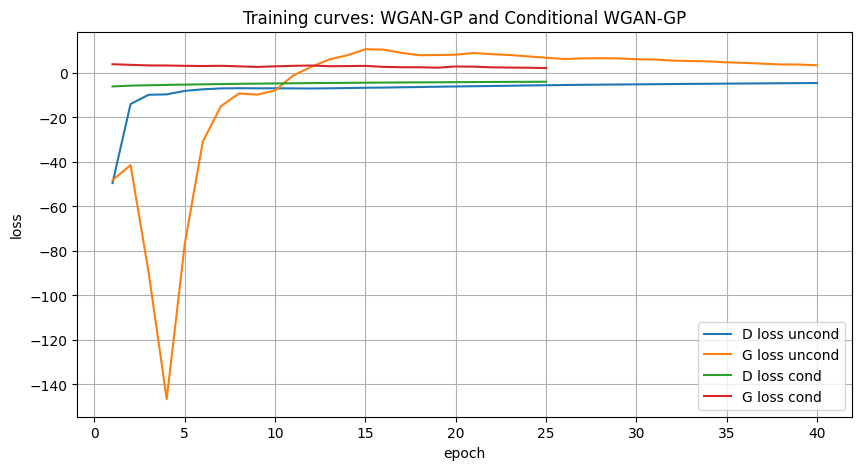

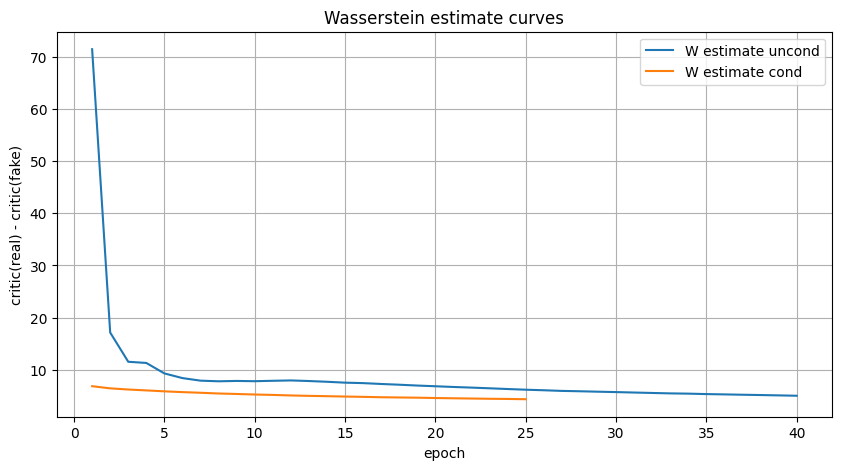

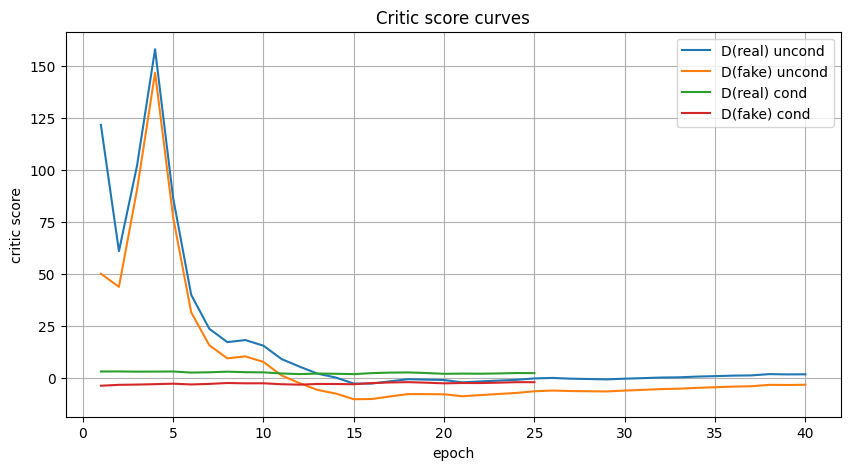

,model,eval_generator,FID,IS_mean,IS_std,n_samples
0,unconditional_wgan_gp,EMA,74.598335,1.855946,0.035194,10000
1,conditional_wgan_gp_Male,EMA,57.237724,1.981005,0.038769,10000


In [ ]:
hist_uncond = pd.read_csv(uncond_dir / "history.csv")
hist_cond = pd.read_csv(cond_dir / "history.csv")

plt.figure(figsize=(10, 5))
plt.plot(hist_uncond["epoch"], hist_uncond["critic_loss"], label="D loss uncond")
plt.plot(hist_uncond["epoch"], hist_uncond["generator_loss"], label="G loss uncond")
plt.plot(hist_cond["epoch"], hist_cond["critic_loss"], label="D loss cond")
plt.plot(hist_cond["epoch"], hist_cond["generator_loss"], label="G loss cond")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training curves: WGAN-GP and Conditional WGAN-GP")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(hist_uncond["epoch"], hist_uncond["wasserstein_est"], label="W estimate uncond")
plt.plot(hist_cond["epoch"], hist_cond["wasserstein_est"], label="W estimate cond")
plt.xlabel("epoch")
plt.ylabel("critic(real) - critic(fake)")
plt.title("Wasserstein estimate curves")
plt.legend()
plt.grid(True)
plt.show()

if {"real_score", "fake_score"}.issubset(hist_uncond.columns) and {"real_score", "fake_score"}.issubset(hist_cond.columns):
    plt.figure(figsize=(10, 5))
    plt.plot(hist_uncond["epoch"], hist_uncond["real_score"], label="D(real) uncond")
    plt.plot(hist_uncond["epoch"], hist_uncond["fake_score"], label="D(fake) uncond")
    plt.plot(hist_cond["epoch"], hist_cond["real_score"], label="D(real) cond")
    plt.plot(hist_cond["epoch"], hist_cond["fake_score"], label="D(fake) cond")
    plt.xlabel("epoch")
    plt.ylabel("critic score")
    plt.title("Critic score curves")
    plt.legend()
    plt.grid(True)
    plt.show()

display(metrics_df)
